# Kapitola 3: Náhodná veličina

## 3.1 Diskrétní a spojitá náhodná veličina

**Definice 3.1**  
Náhodná veličina je reálná měřitelná funkce $ X : \Omega \rightarrow \mathbb{R} $, která každému výsledku náhodného pokusu přiřazuje reálné číslo.

**Definice 3.2**  

Distribuční funkcí náhodné veličiny  $X$ nazýváme funkci  $F(x) = P(X \leq x)$


**Věta 3.3**  
Vlastnosti distribuční funkce:
- $ 0 \leq F(x) \leq 1 $
- $ \lim_{x \to -\infty} F(x) = 0 $, $ \lim_{x \to +\infty} F(x) = 1 $
- $ F(x) $ je neklesající
- $ F(x) $ je zprava spojitá


### Diskrétní náhodná veličina

In [2]:

import random
import collections

# Simulace hodu kostkou
n = 10
vysledky = [random.randint(1, 6) for _ in range(n)]

# Výpočet relativních četností
cetnosti = collections.Counter(vysledky)
pravdepodobnosti = {k: v/n for k, v in cetnosti.items()}

# Výpis pravděpodobností
for hod, p in sorted(pravdepodobnosti.items()):
    print(f"P(X = {hod}) ≈ {p:.3f}")


P(X = 1) ≈ 0.100
P(X = 2) ≈ 0.200
P(X = 3) ≈ 0.300
P(X = 4) ≈ 0.200
P(X = 5) ≈ 0.200


**Distribuční funkce diskrétní veličiny**

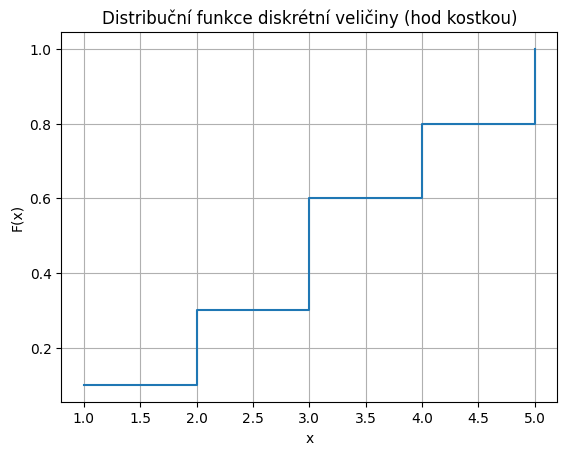

In [4]:
import matplotlib.pyplot as plt
# Výpočet distribuční funkce
hodnoty = sorted(pravdepodobnosti.keys())
F = []
soucet = 0
for h in hodnoty:
    soucet += pravdepodobnosti[h]
    F.append(soucet)

# Graf distribuční funkce
plt.step(hodnoty, F, where='post')
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Distribuční funkce diskrétní veličiny (hod kostkou)")
plt.grid(True)
plt.show()


### Spojitá náhodná veličina


**Definice 3.7**  
Spojitá náhodná veličina má distribuční funkci  
$ F(x) = P(X \leq x) = \int_{-\infty}^{x} f(t) \, dt $  
kde \( f(x) \) je funkce hustoty pravděpodobnosti.

**Věta 3.8**  
Vlastnosti funkce hustoty:
- $ f(x) \geq 0 $
- $ \int_{-\infty}^{\infty} f(x) \, dx = 1 $
- $ P(a < X < b) = \int_a^b f(x) \, dx $


**Simulace spojité náhodné veličiny (normální rozdělení)**

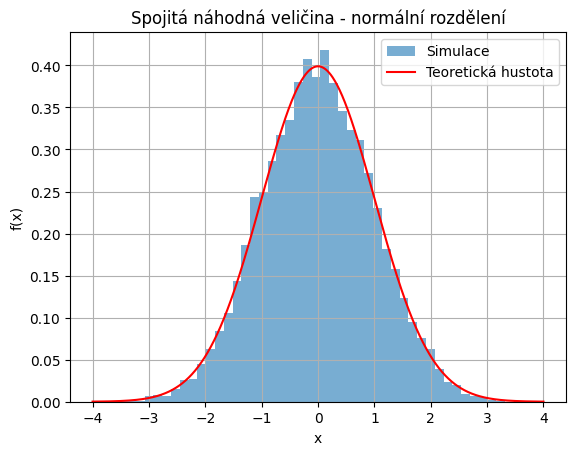

In [24]:
import numpy as np
import matplotlib.pyplot as plt
# Parametry normálního rozdělení
mu = 0
sigma = 1

# Generování dat
data = np.random.normal(mu, sigma, 10000)

# Histogram a hustota
plt.hist(data, bins=50, density=True, alpha=0.6, label="Simulace")
x = np.linspace(-4, 4, 1000)
f = 1/(sigma * np.sqrt(2*np.pi)) * np.exp(-(x - mu)**2 / (2 * sigma**2))
plt.plot(x, f, 'r', label="Teoretická hustota")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Spojitá náhodná veličina - normální rozdělení")
plt.legend()
plt.grid(True)
plt.show()


## 3.2 Charakteristiky náhodné veličiny

### Střední hodnota
**Definice 3.9**  
Střední hodnota náhodné veličiny $X $ je definována jako:  
- Pro **diskrétní** náhodnou veličinu:
$$\mathbb{E}[X] = \sum_{i=1}^{\infty} x_i \cdot P(X = x_i)$$
- Pro **spojitou** náhodnou veličinu:
$$\mathbb{E}[X] = \int_{-\infty}^{\infty} x \cdot f(x) \, \mathrm{d}x$$
Pokud součet řady, resp. integrál existuje.

**Věta 3.10: Vlastnosti střední hodnoty**

Pro náhodné veličiny $X$ a $Y$, pro které existují střední hodnoty, a pro libovolné $c \in \mathbb{R}$ platí:
1. $\mathbb{E}[c] = c$
2. $\mathbb{E}[c \cdot X] = c \cdot \mathbb{E}[X]$
3. $\mathbb{E}[X + Y] = \mathbb{E}[X] + \mathbb{E}[Y]$
4. $P(X \leq Y) = 1 \Rightarrow \mathbb{E}[X] \leq \mathbb{E}[Y]$

**Věta 3.11: Věta o transferu střední hodnoty**

Pro náhodnou veličinu $X$ a funkci $g: \mathbb{R} \to \mathbb{R}$ platí:
- Pro **diskrétní** náhodnou veličinu:
$$\mathbb{E}[g(X)] = \sum_{i=1}^{\infty} g(x_i) \cdot P(X = x_i)$$
- Pro **spojitou** náhodnou veličinu:
$$\mathbb{E}[g(X)] = \int_{-\infty}^{\infty} g(x) \cdot f(x) \, \mathrm{d}x$$
Pokud řady konvergují, resp. integrály existují.


**Příklad náhodných veličin, u kterých střední hodnota neexistuje**


**⚠️ Příklad: Diskrétní náhodná veličina bez střední hodnoty**

Definujme diskrétní náhodnou veličinu $X$ , která nabývá hodnot  $x_i = i$ pro $ i = 1, 2, 3, \dots $$, s pravděpodobnostmi:
$
P(X = i) = \frac{C}{i^p}
$
kde $ p > 1 $ a $ C $ je normovací konstanta.

Pokud $ p \leq 2 $, pak suma
$
\sum_{i=1}^{\infty} i \cdot \frac{1}{i^p} = \sum_{i=1}^{\infty} \frac{1}{i^{p-1}}
$
**diverguje**, protože $ p - 1 \leq 1$ .  
Například pro $ p = 1.5 $ střední hodnota **neexistuje**.

---

**✅ Konkrétní příklad**

Definuj $ X $ takto:
$
P(X = i) = \frac{1}{\zeta(1.5)} \cdot \frac{1}{i^{1.5}}, \quad i = 1, 2, 3, \dots
$
kde $ \zeta(1.5)$ je Riemannova zeta funkce (konverguje pro $ p > 1 $).

Ale:

$
\mathbb{E}[X] = \sum_{i=1}^{\infty} i \cdot \frac{1}{\zeta(1.5)} \cdot \frac{1}{i^{1.5}} = \frac{1}{\zeta(1.5)} \sum_{i=1}^{\infty} \frac{1}{i^{0.5}} = \infty
$

---

** ✏️ Shrnutí**

- Náhodná veličina $ X $ s rozdělením $ P(X = i) = \frac{C}{i^{1.5}} $ je **dobře definovaná** (pravděpodobnosti sečtou na 1),
- ale její **střední hodnota neexistuje**, protože suma $ \sum i \cdot P(X = i) $ diverguje.


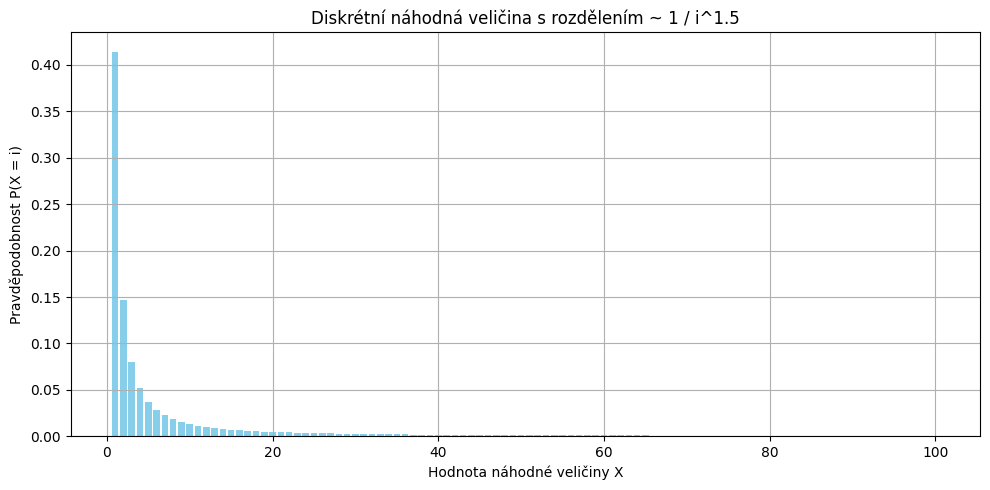

Normovací konstanta C = 0.4144
Střední hodnota (očekávaná hodnota) = 7.7043
Součet nenormovaných členů pro střední hodnotu = 18.5896


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Počet hodnot diskrétní náhodné veličiny
N = 100

# Parametr mocninného rozdělení
p = 1.5

# Výpočet nenormovaných pravděpodobností
i_values = np.arange(1, N + 1)
unnormalized_probs = 1 / i_values**p

# Normovací konstanta C
C = 1 / np.sum(unnormalized_probs)

# Normované pravděpodobnosti
probs = C * unnormalized_probs

# Výpočet střední hodnoty (očekávané hodnoty)
expected_value = np.sum(i_values * probs)

# Výpočet sumy bez normování pro kontrolu divergence
divergent_sum = np.sum(i_values * unnormalized_probs)

# Vykreslení sloupcového grafu pravděpodobností
plt.figure(figsize=(10, 5))
plt.bar(i_values, probs, color='skyblue')
plt.xlabel("Hodnota náhodné veličiny X")
plt.ylabel("Pravděpodobnost P(X = i)")
plt.title("Diskrétní náhodná veličina s rozdělením ~ 1 / i^1.5")
plt.grid(True)
plt.tight_layout()
plt.show()

# Komentář k výpočtu
print(f"Normovací konstanta C = {C:.4f}")
print(f"Střední hodnota (očekávaná hodnota) = {expected_value:.4f}")
print(f"Součet nenormovaných členů pro střední hodnotu = {divergent_sum:.4f}")

# Poznámka:
# I když pravděpodobnosti jsou normované (součet = 1), suma i * P(X = i) bez normování diverguje.
# To znamená, že střední hodnota této náhodné veličiny neexistuje pro p <= 2.

**⚠️ Příklad: Spojitá náhodná veličina bez střední hodnoty**

Definujme spojitou náhodnou veličinu $X$ s hustotou pravděpodobnosti:

$$f(x) = \begin{cases}
\frac{1}{x^2}, & x \geq 1 \\
0, & \text{jinak}
\end{cases}
$$

Tato funkce je validní hustota, protože:
$$
\int_{1}^{\infty} \frac{1}{x^2} \,dx = \left[-\frac{1}{x}\right]_1^{\infty} = 1
$$

Ale její střední hodnota:
$$
\mathbb{E}[X] = \int_{1}^{\infty} x \cdot \frac{1}{x^2} \, dx = \int_{1}^{\infty} \frac{1}{x} \, dx = \infty
$$
**neexistuje**, protože integrál diverguje.


In [26]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Definice hustoty f(x) = 1 / x^2 pro x >= 1
def f(x):
    return 1 / x**2 if x >= 1 else 0

# Vytvoření dat pro graf
x_vals = np.linspace(1, 10, 500)
y_vals = [f(x) for x in x_vals]

# Výpočet střední hodnoty: E[X] = ∫ x * f(x) dx = ∫ x / x^2 dx = ∫ 1/x dx od 1 do ∞
def integrand(x):
    return x * f(x)

# Pokus o výpočet integrálu
mean_value, error = quad(integrand, 1, np.inf, limit=100, epsabs=1e-5)


C:\Users\sediva\AppData\Local\Temp\ipykernel_30028\3335563581.py:18: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  mean_value, error = quad(integrand, 1, np.inf, limit=100, epsabs=1e-5)


### Rozptyl

**Definice 3.12**
Rozptyl náhodné veličiny $X$ je definován vztahem:
$$\mathrm{Var}[X] \overset{\text{def}}{=} \mathbb{E}[(X - \mathbb{E}[X])^2]$$
Směrodatná odchylka $\sigma_X$ je odmocnina z rozptylu.

**Věta 3.13: Vlastnosti rozptylu**
Pro náhodnou veličinu $X$, pro kterou existuje rozptyl, a pro libovolné $a \in \mathbb{R}$ platí:
1. $\mathrm{Var}[X] \geq 0$ a navíc $\mathrm{Var}[X] = 0 \Leftrightarrow \exists c \in \mathbb{R}: P(X = c) = 1$
2. $\mathrm{Var}[c] = 0$
3. $\mathrm{Var}[X] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$
4. $\mathrm{Var}[c \cdot X] = c^2 \cdot \mathrm{Var}[X]$

**Výpočtový tvar pro diskrétní náhodnou veličinu:**
$$\mathrm{Var}[X] = \sum_{i=1}^{\infty} x_i^2 \cdot P(X = x_i) - (\mathbb{E}[X])^2$$
**Výpočtový tvar pro spojitou náhodnou veličinu:**
$$\mathrm{Var}[X] = \int_{-\infty}^{\infty} x^2 \cdot f(x) \, \mathrm{d}x - (\mathbb{E}[X])^2$$
Poznámka: Vztah $\mathrm{Var}[X + Y] = \mathrm{Var}[X] + \mathrm{Var}[Y]$ neplatí obecně, platí například pro nezávislé náhodné veličiny.

In [27]:
import numpy as np

# Vygenerujeme závislé náhodné veličiny X a Y
np.random.seed(42)
n = 10000000
X = np.random.normal(loc=0, scale=1, size=n)
Y = np.random.normal(loc=0, scale=1, size=n) # Y jsou nezávislá na X
Y = 2*X+4  # Y je zcela závislá na X

# Výpočet rozptylů
var_X = np.var(X)
var_Y = np.var(Y)
var_X_plus_Y = np.var(X + Y)

# Výpis výsledků
print("Rozptyl Var[X]:", var_X)
print("Rozptyl Var[Y]:", var_Y)
print("Rozptyl Var[X + Y]:", var_X_plus_Y)
print("Součet Var[X] + Var[Y]:", var_X + var_Y)
print("Rozdíl Var[X + Y] - (Var[X] + Var[Y]):", var_X_plus_Y - (var_X + var_Y))

Rozptyl Var[X]: 1.0000271631213848
Rozptyl Var[Y]: 4.000108652485539
Rozptyl Var[X + Y]: 9.00024446809248
Součet Var[X] + Var[Y]: 5.000135815606924
Rozdíl Var[X + Y] - (Var[X] + Var[Y]): 4.000108652485556


**Věta 3.13: Čebyševova nerovnost**
Nechť $\mathrm{Var}(X) < \infty$ a $\varepsilon > 0$, pak platí:
$P(|X - \mathbb{E}[X]| \geq \varepsilon) \leq \frac{\mathrm{Var}(X)}{\varepsilon^2}$

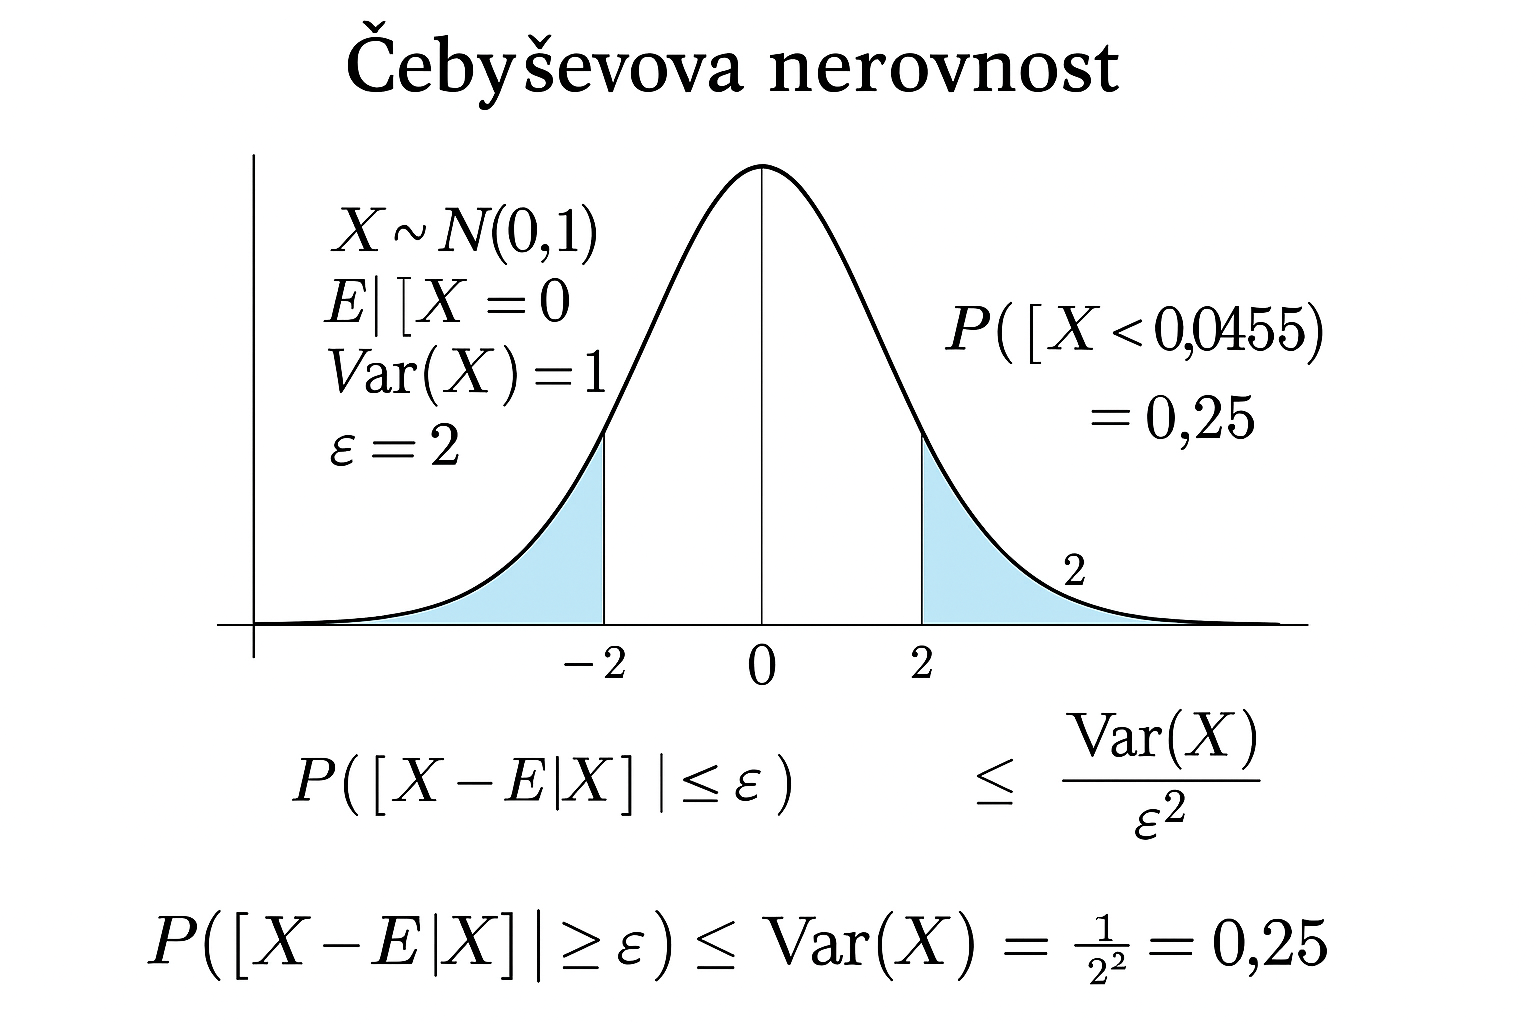

### Obecné momenty náhodné veličiny

**Definice 3.14 : Momenty náhodné veličiny**
Pro náhodnou veličinu $X$ a přirozené číslo $n$ definujeme:
- $n$-tý obecný moment $\mu'_n = \mathbb{E}[X^n]$
- $n$-tý centrální moment $\mu_n = \mathbb{E}[(X - \mathbb{E}[X])^n]$
- šikmost $\gamma_3 = \frac{\mu_3}{(\sqrt{\mathrm{Var}[X]})^3}$
- špičatost $\gamma_4 = \frac{\mu_4}{(\mathrm{Var}[X])^2} - 3$



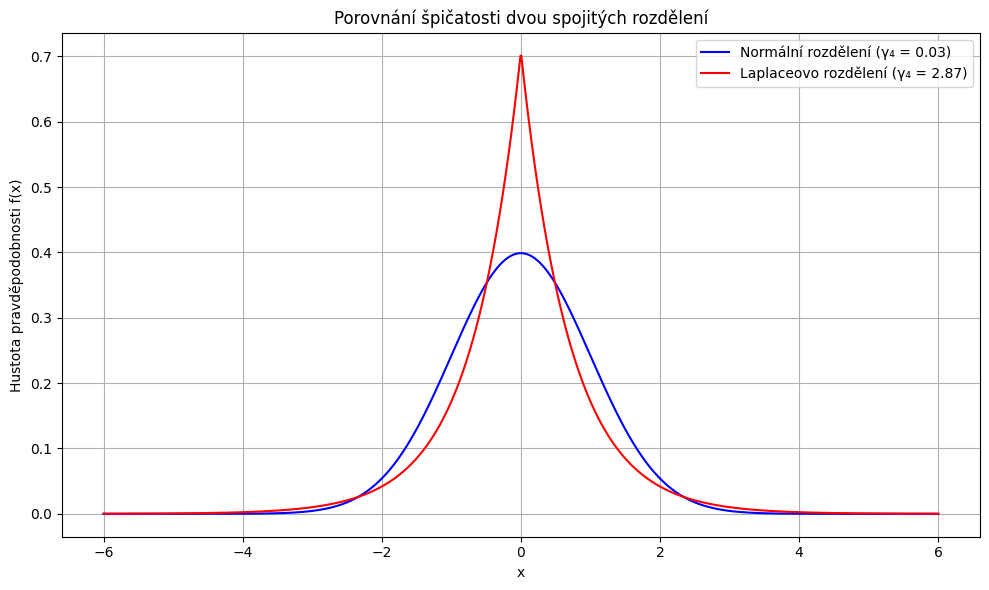

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, norm, laplace

# Nastavení parametrů
np.random.seed(42)
n = 10000

# Generování dat
data_normal = np.random.normal(loc=0, scale=1, size=n)
data_laplace = np.random.laplace(loc=0, scale=1/np.sqrt(2), size=n)  # stejné rozptyl jako normální

# Výpočet špičatosti
kurt_normal = kurtosis(data_normal, fisher=True)
kurt_laplace = kurtosis(data_laplace, fisher=True)

# Vytvoření hustot
x = np.linspace(-6, 6, 1000)
pdf_normal = norm.pdf(x, loc=0, scale=1)
pdf_laplace = laplace.pdf(x, loc=0, scale=1/np.sqrt(2))

# Vykreslení grafu
plt.figure(figsize=(10, 6))
plt.plot(x, pdf_normal, label=f'Normální rozdělení (γ₄ = {kurt_normal:.2f})', color='blue')
plt.plot(x, pdf_laplace, label=f'Laplaceovo rozdělení (γ₄ = {kurt_laplace:.2f})', color='red')
plt.title('Porovnání špičatosti dvou spojitých rozdělení')
plt.xlabel('x')
plt.ylabel('Hustota pravděpodobnosti f(x)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("porovnani_spicatosti.png")
plt.show()

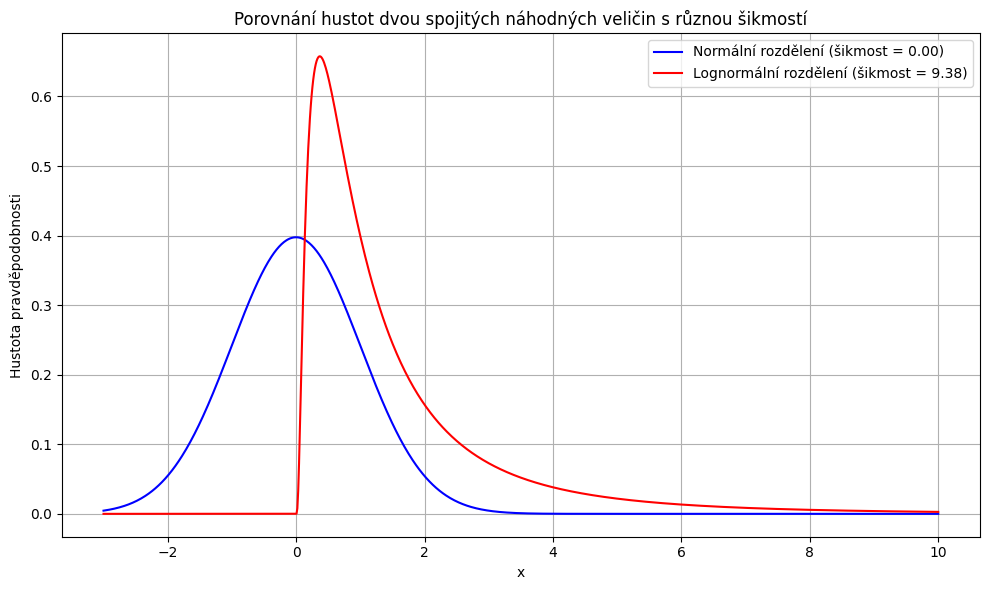

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, norm, lognorm

# Nastavení náhodného semene pro reprodukovatelnost
np.random.seed(42)

# Generování dat pro normální rozdělení (šikmost ≈ 0)
normal_data = np.random.normal(loc=0, scale=1, size=10000)

# Generování dat pro lognormální rozdělení (kladná šikmost)
lognormal_data = np.random.lognormal(mean=0, sigma=1, size=10000)

# Výpočet šikmosti
skew_normal = skew(normal_data)
skew_lognormal = skew(lognormal_data)

# Vykreslení hustot
x = np.linspace(-3, 10, 1000)
normal_pdf = norm.pdf(x, loc=np.mean(normal_data), scale=np.std(normal_data))
lognormal_pdf = lognorm.pdf(x, s=1, scale=np.exp(0))

plt.figure(figsize=(10, 6))
plt.plot(x, normal_pdf, label=f'Normální rozdělení (šikmost = {skew_normal:.2f})', color='blue')
plt.plot(x, lognormal_pdf, label=f'Lognormální rozdělení (šikmost = {skew_lognormal:.2f})', color='red')
plt.title('Porovnání hustot dvou spojitých náhodných veličin s různou šikmostí')
plt.xlabel('x')
plt.ylabel('Hustota pravděpodobnosti')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("porovnani_sikmosti.png")
plt.show()